In [364]:
from pathlib import Path
from glob import glob
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import os

BASE_DIR = Path(r"C:\Users\milan\OneDrive\Desktop\Academic Files\01 - Academic Year\03 - Year 3\01 - EC3400 Dissertation")

## Data Loading

In [365]:
files = glob(str(BASE_DIR / "Data" / "Monthly Settlement Prices" / "*.csv"))

In [366]:
def load_one(fp):

    with open(fp) as f:
        lines = f.readlines()

    header_row = next(i for i,l in enumerate(lines) if l.startswith("Date"))

    df = pd.read_csv(fp, skiprows=header_row)

    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date")

    ticker = os.path.basename(fp).replace("_monthly_settlement.csv", "")

    df = df[["Date","PX_SETTLE"]].rename(columns={"PX_SETTLE": ticker})

    df = df.drop_duplicates(subset=["Date"], keep="last")

    return df

In [367]:
df = load_one(files.pop())

while files:
    df = df.merge(load_one(files.pop()), on="Date", how="outer")

df = df.sort_values("Date").set_index("Date")

In [368]:
df = df.loc["1990":]

## Monthly Returns

Compute returns from settlement prices and filter outliers.

In [369]:
returns = df.pct_change(fill_method=None)

In [370]:
returns = returns.where(returns.abs() < 0.8)

Compute 12-month cumulative returns and generate trend signals.

In [371]:
past_12m = (1 + returns).rolling(12).apply(np.prod, raw=True) - 1

In [372]:
signal = np.sign(past_12m)

## Daily Volatility

Estimate annualised volatility from daily returns using EWMA (delta = 60/61).

In [373]:
daily_data_files = glob(str(BASE_DIR / "Data" / "Daily Settlement Prices" / "*.csv"))

In [374]:
def load_one_daily(fp):

    with open(fp) as f:
        lines = f.readlines()

    header_row = next(i for i, l in enumerate(lines) if l.startswith("Date"))

    df = pd.read_csv(fp, skiprows=header_row)

    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date")

    ticker = os.path.basename(fp).replace("_daily_settlement.csv", "")

    df = df[["Date", "PX_SETTLE"]].rename(columns={"PX_SETTLE": ticker})

    df = df.drop_duplicates(subset=["Date"], keep="last")

    return df

In [375]:
df_daily = load_one_daily(daily_data_files.pop(0))

while daily_data_files:
    df_daily = df_daily.merge(load_one_daily(daily_data_files.pop(0)), on="Date", how="outer")

df_daily = df_daily.sort_values("Date").set_index("Date")

In [376]:
df_daily = df_daily.loc["1990":]

In [377]:
daily_returns = df_daily.pct_change(fill_method=None)

In [378]:
daily_returns = daily_returns.where(daily_returns.abs() < 0.8)

In [379]:
delta = 60/61

In [380]:
ewma_mean = daily_returns.ewm(alpha=(1-delta), adjust=False).mean()

In [381]:
ewma_var = ((daily_returns - ewma_mean)**2).ewm(alpha=(1-delta), adjust=False).mean()

In [382]:
daily_vol = np.sqrt(261 * ewma_var)

In [383]:
monthly_vol = daily_vol.resample("ME").last()

## TSMOM Construction

Align indices and build the equal-weighted TSMOM portfolio with 40% volatility target.

In [384]:
returns = returns.sort_index()
signal = signal.sort_index()
monthly_vol = monthly_vol.sort_index()

returns.index = pd.to_datetime(returns.index).to_period("M").to_timestamp("M")
signal.index = pd.to_datetime(signal.index).to_period("M").to_timestamp("M")
monthly_vol.index = pd.to_datetime(monthly_vol.index).to_period("M").to_timestamp("M")

common_index = returns.index.intersection(signal.index).intersection(monthly_vol.index)

returns = returns.reindex(common_index)
signal = signal.reindex(common_index)
monthly_vol = monthly_vol.reindex(common_index)

common_cols = returns.columns.intersection(signal.columns).intersection(monthly_vol.columns)

returns = returns[common_cols]
signal = signal[common_cols]
monthly_vol = monthly_vol[common_cols]

In [385]:
position = 0.40 / monthly_vol

In [386]:
tsmom_asset = signal.shift(1) * position.shift(1) * returns

In [387]:
tsmom_portfolio = tsmom_asset.mean(axis=1, skipna=True)

In [388]:
tsmom_portfolio_clean = tsmom_portfolio.dropna()

In [389]:
growth = 100 * (1 + tsmom_portfolio_clean).cumprod()

In [390]:
passive_returns = returns.mean(axis=1, skipna=True)

passive_growth = 100 * (1 + passive_returns.dropna()).cumprod()

In [391]:
growth = growth.dropna()
passive_growth = passive_growth.dropna()

growth.index = pd.to_datetime(growth.index)
passive_growth.index = pd.to_datetime(passive_growth.index)



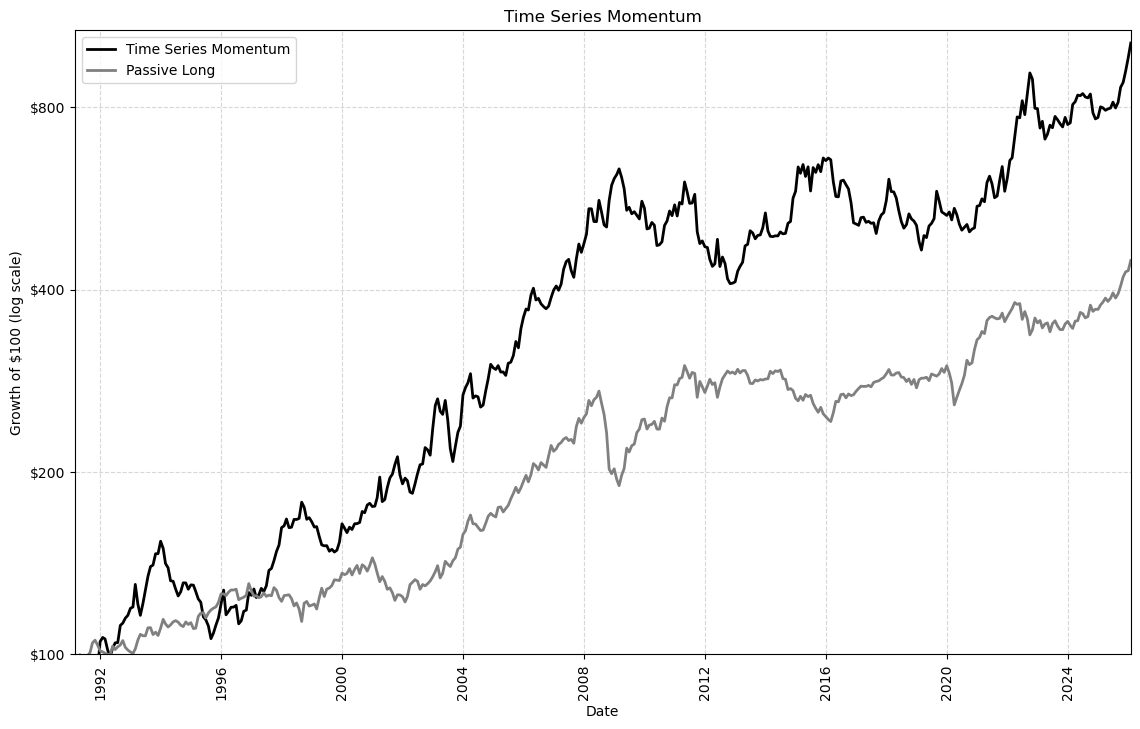

In [392]:
fig, ax = plt.subplots(figsize=(12,8))

ax.plot(growth.index, growth.values, color="black", linewidth=2, label="Time Series Momentum")
ax.plot(passive_growth.index, passive_growth.values, color="gray", linewidth=2, label="Passive Long")

ax.set_yscale("log")


ax.set_xlim(growth.index.min(), growth.index.max())
ax.set_ylim(100, growth.max() * 1.05)

yticks = [100, 200, 400, 800]
ax.set_yticks(yticks)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${int(x)}'))
ax.yaxis.set_minor_locator(ticker.NullLocator())

ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=90)

ax.set_title("Time Series Momentum")
ax.set_ylabel("Growth of $100 (log scale)")
ax.set_xlabel("Date")

ax.legend()
ax.grid(True, which="major", linestyle="--", alpha=0.5)

plt.subplots_adjust(left=0.1, right=0.98, top=0.93, bottom=0.15)
plt.show()

## Sharpe Ratios TSMOM

In [393]:
sharpe_asset = (tsmom_asset.mean() * 12) / (tsmom_asset.std() * np.sqrt(12))

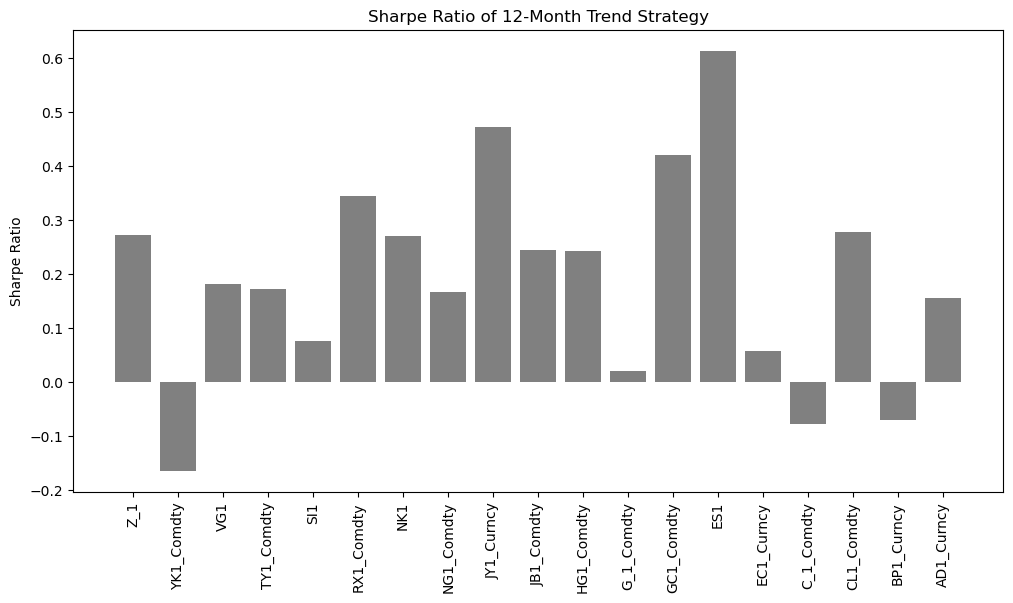

In [394]:
plt.figure(figsize=(12,6))
plt.bar(sharpe_asset.index, sharpe_asset.values, color = "gray")

plt.xticks(rotation=90)

plt.title("Sharpe Ratio of 12-Month Trend Strategy")
plt.ylabel("Sharpe Ratio")

plt.show()

## Factor Data

Load Fama-French factors (MKT, SMB, HML, UMD), MSCI World, Bloomberg US Aggregate Bond, and S&P GSCI.

In [395]:
ff = pd.read_csv(BASE_DIR / "F-F_Research_Data_Factors.csv", skiprows=4)

In [396]:
ff = ff.iloc[:1194]

In [397]:
ff = ff.rename(columns={"Unnamed: 0": "Date"})

In [398]:
ff["Date"] = pd.to_datetime(ff["Date"], format="%Y%m")

In [399]:
cols = ["Mkt-RF", "SMB", "HML", "RF"]

ff[cols] = ff[cols].apply(pd.to_numeric)

In [400]:
cols = ["Mkt-RF", "SMB", "HML", "RF"]
ff[cols] = ff[cols] / 100

In [401]:
umd = pd.read_csv(BASE_DIR / "F-F_Momentum_Factor.csv", skiprows=13)

In [402]:
umd = umd.iloc[:1188]

In [403]:
umd = umd.rename(columns={"Unnamed: 0": "Date"})

In [404]:
umd["Date"] = pd.to_datetime(umd["Date"], format="%Y%m")

In [405]:
cols = ["Mom"]

umd[cols] = umd[cols].apply(pd.to_numeric)

In [406]:
cols = ["Mom"]
umd[cols] = umd[cols] / 100

In [407]:
umd = umd.rename(columns={"Mom": "UMD"})

In [408]:
regression = pd.merge(ff, umd, on="Date", how="inner")

In [409]:
msci = pd.read_csv(BASE_DIR / "MSCI_INDEX.csv", skiprows=6)

In [410]:
msci["Date"] = pd.to_datetime(msci["Date"], dayfirst=True)

In [411]:
msci = msci.sort_values("Date")

In [412]:
msci["MKT"] = msci["PX_LAST"].pct_change()

In [413]:
msci = msci[["Date","MKT"]]

In [414]:
msci = msci.dropna()

In [415]:
msci["Date"] = msci["Date"].dt.to_period("M").dt.to_timestamp()

In [416]:
regression = pd.merge(regression, msci, on="Date", how="inner")

In [417]:
bond = pd.read_csv(BASE_DIR / "LBUSTRUU_monthly_TR.csv", skiprows=5)

In [418]:
bond["Date"] = pd.to_datetime(bond["Date"], dayfirst=True)

In [419]:
bond = bond.sort_values("Date")

In [420]:
bond["BOND"] = bond["PX_LAST"].pct_change()

In [421]:
bond = bond[["Date","BOND"]]

In [422]:
bond = bond.dropna()

In [423]:
bond.loc[:, "Date"] = bond["Date"].dt.to_period("M").dt.to_timestamp()

In [424]:
regression = pd.merge(regression, bond, on="Date", how="inner")

In [425]:
gsci = pd.read_csv(BASE_DIR / "SPGSCITR_monthly_TR.csv", skiprows=6)

In [426]:
gsci["Date"] = pd.to_datetime(gsci["Date"], dayfirst=True)

In [427]:
gsci = gsci.sort_values("Date")

In [428]:
gsci["GSCI"] = gsci["PX_LAST"].pct_change()

In [429]:
gsci = gsci[["Date","GSCI"]]

In [430]:
gsci = gsci.dropna()

In [431]:
gsci.loc[:, "Date"] = gsci["Date"].dt.to_period("M").dt.to_timestamp()

In [432]:
regression = pd.merge(regression, gsci, on="Date", how="inner")

In [433]:
tsmom_df = tsmom_portfolio_clean.reset_index()
tsmom_df.columns = ["Date", "TSMOM"]

In [434]:
tsmom_df["Date"] = pd.to_datetime(tsmom_df["Date"]).dt.to_period("M").dt.to_timestamp()

In [435]:
regression = pd.merge(regression, tsmom_df, on="Date", how="inner")

In [436]:
regression["TSMOM_excess"] = regression["TSMOM"] - regression["RF"]

## TSMOM Regression

In [437]:
y = regression["TSMOM_excess"]

X = regression[["MKT", "BOND", "GSCI", "SMB", "HML", "UMD"]]
X = sm.add_constant(X)

model_tsmom = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

print(model_tsmom.summary())

                            OLS Regression Results                            
Dep. Variable:           TSMOM_excess   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     7.766
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           6.29e-08
Time:                        09:37:40   Log-Likelihood:                 769.52
No. Observations:                 419   AIC:                            -1525.
Df Residuals:                     412   BIC:                            -1497.
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0024      0.003      0.947      0.3

## VM-TSMOM Construction

In [438]:
returns_mm = returns.copy()
signal_mm = signal.copy()
daily_returns_mm = daily_returns.copy()

daily_returns_mm = daily_returns_mm.sort_index()
daily_returns_mm.index = pd.to_datetime(daily_returns_mm.index)

common_cols_mm = returns_mm.columns.intersection(signal_mm.columns).intersection(daily_returns_mm.columns)

returns_mm = returns_mm[common_cols_mm]
signal_mm = signal_mm[common_cols_mm]
daily_returns_mm = daily_returns_mm[common_cols_mm]

In [439]:
signal_lag_mm = signal_mm.shift(1).copy()
signal_lag_mm.index = signal_lag_mm.index.to_period("M")

In [440]:
signal_daily_mm = signal_lag_mm.reindex(daily_returns_mm.index.to_period("M"))
signal_daily_mm.index = daily_returns_mm.index



In [441]:
daily_tsmom_asset_mm = signal_daily_mm * daily_returns_mm
daily_tsmom_asset_mm.head()

,Z_1,YK1_Comdty,VG1,TY1_Comdty,SI1,RX1_Comdty,NK1,NG1_Comdty,JY1_Curncy,JB1_Comdty,HG1_Comdty,G_1_Comdty,GC1_Comdty,ES1,EC1_Curncy,C_1_Comdty,CL1_Comdty,BP1_Curncy,AD1_Curncy
Date,,,,,,,,,,,,,,,,,,,
1990-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [442]:
daily_tsmom_portfolio_mm = daily_tsmom_asset_mm.mean(axis=1, skipna=True)

In [443]:
rv_mm = daily_tsmom_portfolio_mm.groupby(
    daily_tsmom_portfolio_mm.index.to_period("M")
).apply(lambda x: np.mean(x**2))

rv_mm.index = rv_mm.index.to_timestamp("M")
rv_mm.name = "RV"

In [444]:
tsmom_asset_mm = signal_mm.shift(1) * returns_mm
tsmom_portfolio_mm = tsmom_asset_mm.mean(axis=1, skipna=True)

In [445]:
managed_data_mm = pd.concat(
    [tsmom_portfolio_mm.rename("TSMOM"), rv_mm],
    axis=1
).dropna()

managed_data_mm.head(15)

,TSMOM,RV
Date,,
1991-02-28,-0.003133,0.000029
1991-03-31,-0.024534,0.000020
1991-04-30,-0.001234,0.000011
1991-05-31,0.003920,0.000004
1991-06-30,-0.000770,0.000007
1991-07-31,-0.004913,0.000009
1991-08-31,0.001764,0.000014
1991-09-30,0.002102,0.000006
1991-10-31,-0.003177,0.000010


In [446]:
managed_data_mm["VM_raw"] = managed_data_mm["TSMOM"] / managed_data_mm["RV"].shift(1)

In [447]:
valid_mm = managed_data_mm[["TSMOM","VM_raw"]].dropna()

c_mm = valid_mm["TSMOM"].std() / valid_mm["VM_raw"].std()
c_mm

1.3257768048351686e-05

In [448]:
managed_data_mm["VM_TSMOM"] = c_mm * managed_data_mm["VM_raw"]

vm_tsmom = managed_data_mm["VM_TSMOM"].dropna()
vm_tsmom.head(15)

Date
1991-03-31   -0.011182
1991-04-30   -0.000822
1991-05-31    0.004821
1991-06-30   -0.002585
1991-07-31   -0.008692
1991-08-31    0.002526
1991-09-30    0.002034
1991-10-31   -0.006657
1991-11-30    0.006055
1991-12-31    0.064656
1992-01-31    0.008745
1992-02-29   -0.000567
1992-03-31   -0.018824
1992-04-30   -0.028297
1992-05-31    0.004335
Freq: ME, Name: VM_TSMOM, dtype: float64

In [449]:
vm_growth = 100 * (1 + vm_tsmom).cumprod()

## Combined Cumulative Returns

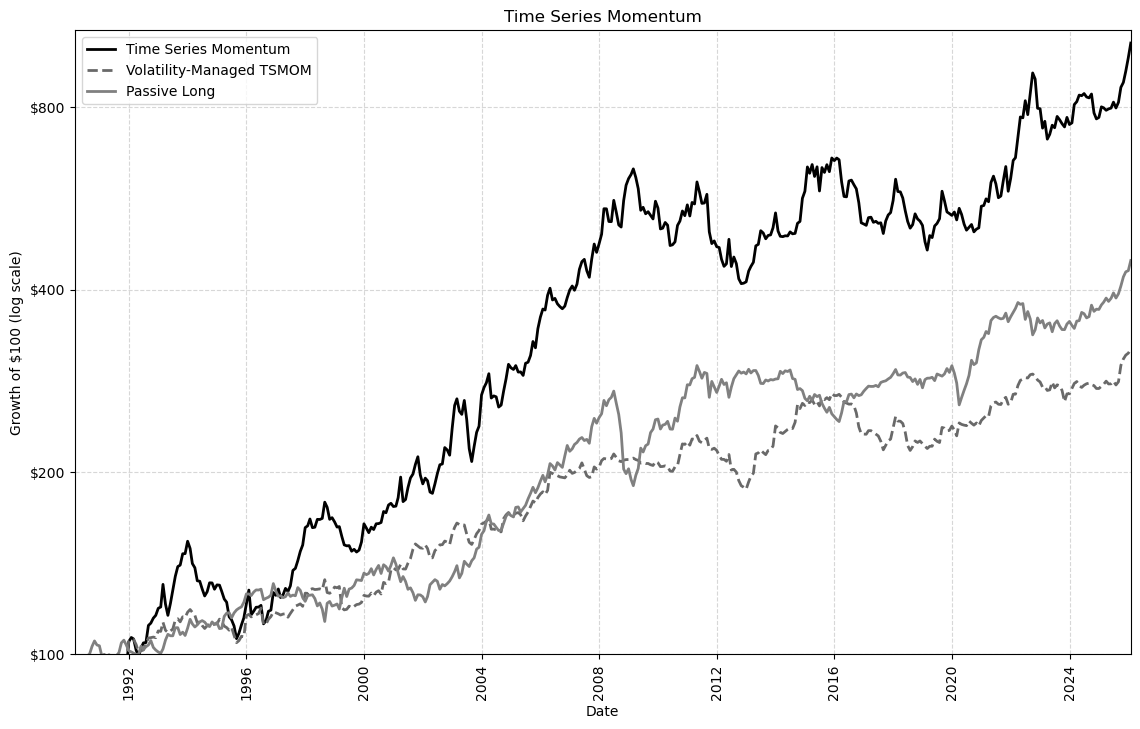

In [450]:
fig, ax = plt.subplots(figsize=(12,8))

ax.plot(growth.index, growth.values, color="black", linewidth=2, label="Time Series Momentum")
ax.plot(vm_growth.index, vm_growth.values, color="dimgray", linewidth=2, linestyle="--", label="Volatility-Managed TSMOM")
ax.plot(passive_growth.index, passive_growth.values, color="gray", linewidth=2, label="Passive Long")

ax.set_yscale("log")


ax.set_xlim(min(growth.index.min(), vm_growth.index.min(), passive_growth.index.min()),
            max(growth.index.max(), vm_growth.index.max(), passive_growth.index.max()))
ax.set_ylim(100, max(growth.max(), vm_growth.max(), passive_growth.max()) * 1.05)

yticks = [100, 200, 400, 800]
ax.set_yticks(yticks)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${int(x)}'))
ax.yaxis.set_minor_locator(ticker.NullLocator())

ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=90)

ax.set_title("Time Series Momentum")
ax.set_ylabel("Growth of $100 (log scale)")
ax.set_xlabel("Date")

ax.legend()
ax.grid(True, which="major", linestyle="--", alpha=0.5)

plt.subplots_adjust(left=0.1, right=0.98, top=0.93, bottom=0.15)
plt.show()

In [451]:
managed_data_mm["weight"] = c_mm / managed_data_mm["RV"].shift(1)
managed_data_mm["weight"].describe()

count    419.000000
mean       1.089560
std        0.820137
min        0.042623
25%        0.553496
50%        0.882856
75%        1.397650
max        5.369221
Name: weight, dtype: float64

## Sharpe Ratio per Asset - VM-TSMOM

In [452]:
vm_weight = c_mm / managed_data_mm["RV"].shift(1)
vm_weight = vm_weight.reindex(tsmom_asset_mm.index)

In [453]:
vm_asset = tsmom_asset_mm.mul(vm_weight, axis=0)

In [454]:
vm_sharpe_asset = (vm_asset.mean() * 12) / (vm_asset.std() * np.sqrt(12))

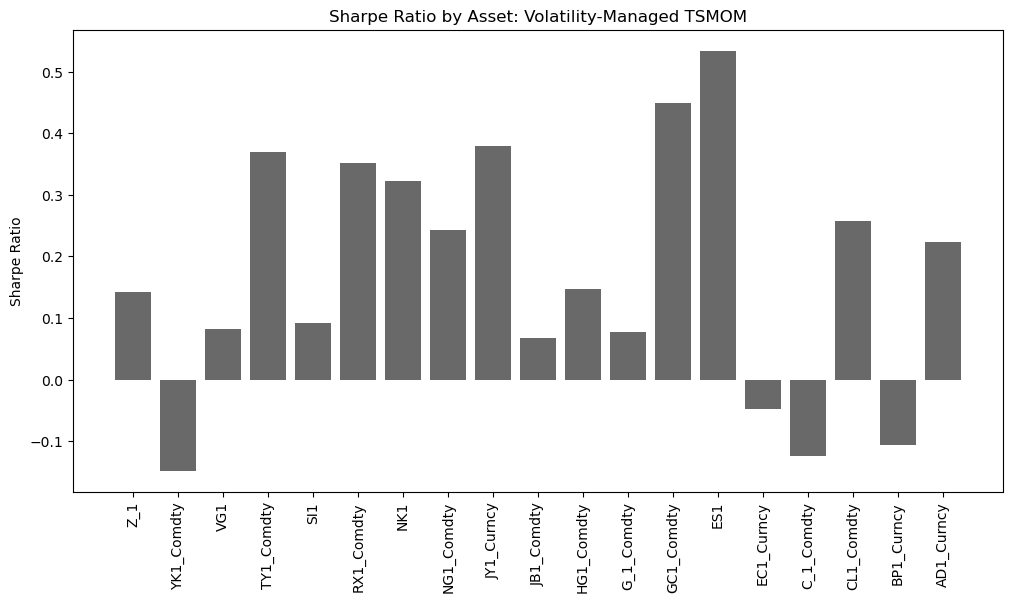

In [455]:
plt.figure(figsize=(12,6))

plt.bar(vm_sharpe_asset.index, vm_sharpe_asset.values, color="dimgray")

plt.xticks(rotation=90)

plt.title("Sharpe Ratio by Asset: Volatility-Managed TSMOM")
plt.ylabel("Sharpe Ratio")

plt.show()

## Comparative Results Table

In [456]:
data = pd.concat([
    passive_returns.rename("Passive"),
    tsmom_portfolio_clean.rename("TSMOM"),
    vm_tsmom.rename("VM-TSMOM")
], axis=1).dropna()

data.head()

,Passive,TSMOM,VM-TSMOM
Date,,,
1991-03-31,-0.007755,-0.068953,-0.011182
1991-04-30,0.006541,0.013743,-0.000822
1991-05-31,-0.009065,-0.001138,0.004821
1991-06-30,-0.017884,-0.016692,-0.002585
1991-07-31,0.023480,-0.009221,-0.008692


In [457]:
ann_return = data.mean() * 12

In [458]:
ann_vol = data.std() * np.sqrt(12)

In [459]:
sharpe = ann_return / ann_vol

In [460]:
growth = (1 + data).cumprod()
drawdown = growth / growth.cummax() - 1
max_dd = drawdown.min()

In [461]:
performance_table = pd.DataFrame({
    "Annual Return": ann_return,
    "Volatility": ann_vol,
    "Sharpe": sharpe,
    "Max Drawdown": max_dd
})

performance_table.round(3)

,Annual Return,Volatility,Sharpe,Max Drawdown
Passive,0.047,0.084,0.554,-0.302
TSMOM,0.078,0.143,0.544,-0.354
VM-TSMOM,0.036,0.067,0.527,-0.195


## VM-TSMOM Regression

In [462]:
vm_df = vm_tsmom.reset_index()
vm_df.columns = ["Date", "VM_TSMOM"]

In [463]:
vm_df["Date"] = pd.to_datetime(vm_df["Date"]).dt.to_period("M").dt.to_timestamp()

In [464]:
regression = pd.merge(regression, vm_df, on="Date", how="inner")

In [465]:
regression["VM_TSMOM_excess"] = regression["VM_TSMOM"] - regression["RF"]

In [466]:
y = regression["VM_TSMOM_excess"]

X = regression[["MKT", "BOND", "GSCI", "SMB", "HML", "UMD"]]
X = sm.add_constant(X)

model_vm = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

print(model_vm.summary())

                            OLS Regression Results                            
Dep. Variable:        VM_TSMOM_excess   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     6.145
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           3.48e-06
Time:                        09:37:44   Log-Likelihood:                 1069.6
No. Observations:                 418   AIC:                            -2125.
Df Residuals:                     411   BIC:                            -2097.
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0004      0.001     -0.337      0.7

## Return-Matched Comparison

In [467]:
# Equal-return scaling: VM-TSMOM matched to TSMOM mean return

equal_return_data = pd.concat([
    passive_returns.rename("Passive"),
    tsmom_portfolio_clean.rename("TSMOM"),
    vm_tsmom.rename("VM_TSMOM")
], axis=1).dropna()

# Scale factor so VM-TSMOM matches TSMOM average monthly return
scale_factor = equal_return_data["TSMOM"].mean() / equal_return_data["VM_TSMOM"].mean()
equal_return_data["VM_TSMOM_equal_return"] = equal_return_data["VM_TSMOM"] * scale_factor

print(f"Scale factor applied to VM-TSMOM: {scale_factor:.3f}")

# Plot cumulative returns
growth_equal = 100 * (1 + equal_return_data[["Passive", "TSMOM", "VM_TSMOM_equal_return"]]).cumprod()



Scale factor applied to VM-TSMOM: 2.183


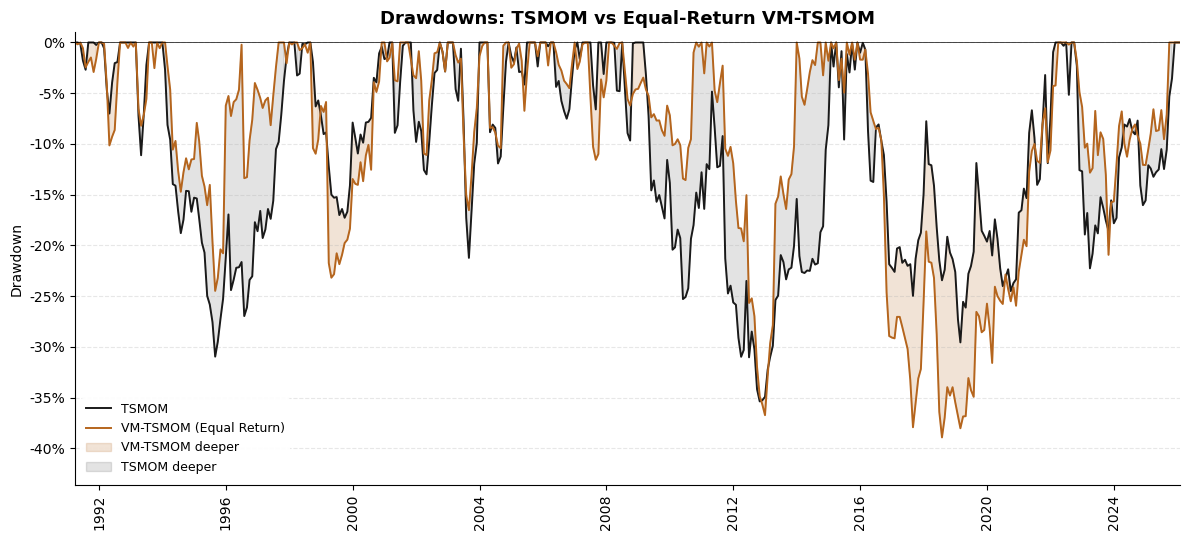

In [468]:
dd_data = equal_return_data[["TSMOM", "VM_TSMOM_equal_return"]].dropna()

wealth_tsmom = (1 + dd_data["TSMOM"]).cumprod()
wealth_vm    = (1 + dd_data["VM_TSMOM_equal_return"]).cumprod()

dd_tsmom = wealth_tsmom / wealth_tsmom.cummax() - 1
dd_vm    = wealth_vm / wealth_vm.cummax() - 1

fig, ax = plt.subplots(figsize=(12, 5.5))

ax.plot(dd_tsmom.index, dd_tsmom.values, color="#1a1a1a", linewidth=1.4, label="TSMOM")
ax.plot(dd_vm.index, dd_vm.values, color="#b5651d", linewidth=1.4, label="VM-TSMOM (Equal Return)")

# Shade region where VM-TSMOM drawdown is deeper
ax.fill_between(dd_tsmom.index, dd_tsmom.values, dd_vm.values,
                where=(dd_vm < dd_tsmom), color="#b5651d", alpha=0.18,
                label="VM-TSMOM deeper")
ax.fill_between(dd_tsmom.index, dd_tsmom.values, dd_vm.values,
                where=(dd_tsmom < dd_vm), color="#1a1a1a", alpha=0.12,
                label="TSMOM deeper")

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_ylim(min(dd_tsmom.min(), dd_vm.min()) * 1.12, 0.01)

ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlim(dd_tsmom.index.min(), dd_tsmom.index.max())
plt.xticks(rotation=90)

ax.set_title("Drawdowns: TSMOM vs Equal-Return VM-TSMOM", fontsize=13, fontweight="bold")
ax.set_ylabel("Drawdown")
ax.set_xlabel("")

ax.legend(loc="lower left", fontsize=9, framealpha=0.95, edgecolor="none")
ax.grid(True, axis="y", linestyle="--", alpha=0.3)
ax.axhline(0, color="black", linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [469]:
comparison = equal_return_data[["Passive", "TSMOM", "VM_TSMOM_equal_return"]]

ann_return = comparison.mean() * 12
ann_vol = comparison.std() * np.sqrt(12)
sharpe = ann_return / ann_vol

growth_stats = (1 + comparison).cumprod()
drawdown = growth_stats / growth_stats.cummax() - 1
max_drawdown = drawdown.min()

equal_return_stats = pd.DataFrame({
    "Annual Return": ann_return,
    "Volatility": ann_vol,
    "Sharpe Ratio": sharpe,
    "Max Drawdown": max_drawdown
})

equal_return_stats.round(3)

,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
Passive,0.047,0.084,0.554,-0.302
TSMOM,0.078,0.143,0.544,-0.354
VM_TSMOM_equal_return,0.078,0.147,0.527,-0.389


## Transaction Costs

Estimate portfolio turnover and evaluate performance net of 5 bps and 10 bps transaction costs.

In [470]:
raw_tsmom_weights = signal.shift(1) * position.shift(1)

raw_tsmom_weights = raw_tsmom_weights.loc[tsmom_portfolio_clean.index]

# Portfolio weights: divide by number of active assets
active_assets = raw_tsmom_weights.notna().sum(axis=1)
tsmom_weights = raw_tsmom_weights.div(active_assets, axis=0)

vm_weight_aligned = vm_weight.reindex(tsmom_weights.index)
vm_weights = tsmom_weights.mul(vm_weight_aligned, axis=0)

tsmom_turnover = tsmom_weights.diff().abs().sum(axis=1) / 2
vm_turnover = vm_weights.diff().abs().sum(axis=1) / 2

tsmom_turnover = tsmom_turnover.dropna()
vm_turnover = vm_turnover.dropna()

tc_data = pd.concat([
    tsmom_portfolio_clean.rename("TSMOM_gross"),
    vm_tsmom.rename("VM_TSMOM_gross"),
    tsmom_turnover.rename("TSMOM_turnover"),
    vm_turnover.rename("VM_TSMOM_turnover")
], axis=1).dropna()

tc_data.head()

,TSMOM_gross,VM_TSMOM_gross,TSMOM_turnover,VM_TSMOM_turnover
Date,,,,
1991-03-31,-0.068953,-0.011182,0.972173,0.000000
1991-04-30,0.013743,-0.000822,0.210881,0.383916
1991-05-31,-0.001138,0.004821,0.108752,0.824593
1991-06-30,-0.016692,-0.002585,0.507656,4.031764
1991-07-31,-0.009221,-0.008692,0.549357,3.220575


In [471]:
for cost in [0.0005, 0.0010]:
    label = f"{int(cost * 10000)}bps"
    tc_data[f"TSMOM_net_{label}"] = tc_data["TSMOM_gross"] - cost * tc_data["TSMOM_turnover"]
    tc_data[f"VM_TSMOM_net_{label}"] = tc_data["VM_TSMOM_gross"] - cost * tc_data["VM_TSMOM_turnover"]

tc_data.head()

,TSMOM_gross,VM_TSMOM_gross,TSMOM_turnover,VM_TSMOM_turnover,TSMOM_net_5bps,VM_TSMOM_net_5bps,TSMOM_net_10bps,VM_TSMOM_net_10bps
Date,,,,,,,,
1991-03-31,-0.068953,-0.011182,0.972173,0.000000,-0.069439,-0.011182,-0.069925,-0.011182
1991-04-30,0.013743,-0.000822,0.210881,0.383916,0.013638,-0.001014,0.013532,-0.001206
1991-05-31,-0.001138,0.004821,0.108752,0.824593,-0.001193,0.004409,-0.001247,0.003997
1991-06-30,-0.016692,-0.002585,0.507656,4.031764,-0.016946,-0.004600,-0.017200,-0.006616
1991-07-31,-0.009221,-0.008692,0.549357,3.220575,-0.009495,-0.010302,-0.009770,-0.011912


In [472]:
def performance_stats(returns_df):
    ann_return = returns_df.mean() * 12
    ann_vol = returns_df.std() * np.sqrt(12)
    sharpe = ann_return / ann_vol

    growth = (1 + returns_df).cumprod()
    drawdown = growth / growth.cummax() - 1
    max_dd = drawdown.min()

    out = pd.DataFrame({
        "Annual Return": ann_return,
        "Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd
    })
    return out

tc_perf_5bps = performance_stats(tc_data[["TSMOM_net_5bps", "VM_TSMOM_net_5bps"]])
tc_perf_10bps = performance_stats(tc_data[["TSMOM_net_10bps", "VM_TSMOM_net_10bps"]])

print("Performance after 5 bps transaction costs")
display(tc_perf_5bps.round(3))

print("Performance after 10 bps transaction costs")
display(tc_perf_10bps.round(3))

Performance after 5 bps transaction costs


,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
TSMOM_net_5bps,0.074,0.143,0.518,-0.362
VM_TSMOM_net_5bps,0.025,0.067,0.375,-0.253


Performance after 10 bps transaction costs


,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
TSMOM_net_10bps,0.070,0.142,0.492,-0.369
VM_TSMOM_net_10bps,0.015,0.067,0.222,-0.312


In [473]:
gross_vs_net = performance_stats(tc_data[[
    "TSMOM_gross", "VM_TSMOM_gross",
    "TSMOM_net_5bps", "VM_TSMOM_net_5bps",
    "TSMOM_net_10bps", "VM_TSMOM_net_10bps"
]])

gross_vs_net.round(3)

,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
TSMOM_gross,0.078,0.143,0.544,-0.354
VM_TSMOM_gross,0.036,0.067,0.527,-0.195
TSMOM_net_5bps,0.074,0.143,0.518,-0.362
VM_TSMOM_net_5bps,0.025,0.067,0.375,-0.253
TSMOM_net_10bps,0.070,0.142,0.492,-0.369
VM_TSMOM_net_10bps,0.015,0.067,0.222,-0.312


In [474]:
turnover_summary = pd.DataFrame({
    "Average Monthly Turnover": [tc_data["TSMOM_turnover"].mean(), tc_data["VM_TSMOM_turnover"].mean()],
    "Median Monthly Turnover": [tc_data["TSMOM_turnover"].median(), tc_data["VM_TSMOM_turnover"].median()]
}, index=["TSMOM", "VM_TSMOM"])

turnover_summary.round(3)

,Average Monthly Turnover,Median Monthly Turnover
TSMOM,0.614,0.522
VM_TSMOM,1.715,1.235


## Asset Summary

In [475]:
# Exact mapping for your columns
asset_info = {
    "YK1_Comdty": {"Asset class": "Commodity futures", "Contract": "WHEAT"},
    "NG1_Comdty": {"Asset class": "Commodity futures", "Contract": "NATURAL GAS"},
    "HG1_Comdty": {"Asset class": "Commodity futures", "Contract": "COPPER"},
    "G_1_Comdty": {"Asset class": "Commodity futures", "Contract": "SOYBEANS"},
    "GC1_Comdty": {"Asset class": "Commodity futures", "Contract": "GOLD"},
    "C_1_Comdty": {"Asset class": "Commodity futures", "Contract": "CORN"},
    "CL1_Comdty": {"Asset class": "Commodity futures", "Contract": "CRUDE OIL"},
    "SI1": {"Asset class": "Commodity futures", "Contract": "SILVER"},

    "Z_1": {"Asset class": "Equity index futures", "Contract": "FTSE 100"},
    "VG1": {"Asset class": "Equity index futures", "Contract": "EURO STOXX 50"},
    "NK1": {"Asset class": "Equity index futures", "Contract": "NIKKEI 225"},
    "ES1": {"Asset class": "Equity index futures", "Contract": "S&P 500"},

    "TY1_Comdty": {"Asset class": "Bond futures", "Contract": "US 10-YEAR NOTE"},
    "RX1_Comdty": {"Asset class": "Bond futures", "Contract": "EURO-BUND"},
    "JB1_Comdty": {"Asset class": "Bond futures", "Contract": "JAPAN 10-YEAR BOND"},

    "JY1_Curncy": {"Asset class": "Currency futures", "Contract": "JPY/USD"},
    "EC1_Curncy": {"Asset class": "Currency futures", "Contract": "EUR/USD"},
    "BP1_Curncy": {"Asset class": "Currency futures", "Contract": "GBP/USD"},
    "AD1_Curncy": {"Asset class": "Currency futures", "Contract": "AUD/USD"},
}

rows = []

for col in returns.columns:
    s = returns[col].dropna()
    if s.empty:
        continue

    rows.append({
        "Asset class": asset_info[col]["Asset class"],
        "Contract": asset_info[col]["Contract"],
        "Data start date": s.index.min().strftime("%b-%y"),
        "Annualised mean": s.mean() * 12 * 100,
        "Annualised volatility": s.std() * np.sqrt(12) * 100
    })

table1 = pd.DataFrame(rows)

# Order of groups
asset_order = [
    "Commodity futures",
    "Equity index futures",
    "Bond futures",
    "Currency futures"
]

table1["Asset class"] = pd.Categorical(
    table1["Asset class"],
    categories=asset_order,
    ordered=True
)

table1 = table1.sort_values(["Asset class", "Contract"]).reset_index(drop=True)

# Format percentages like the TSMOM paper
table1["Annualised mean"] = table1["Annualised mean"].map(lambda x: f"{x:.2f}%")
table1["Annualised volatility"] = table1["Annualised volatility"].map(lambda x: f"{x:.2f}%")

table1

,Asset class,Contract,Data start date,Annualised mean,Annualised volatility
0,Commodity futures,COPPER,Feb-90,8.03%,24.66%
1,Commodity futures,CORN,Feb-90,5.44%,27.47%
2,Commodity futures,CRUDE OIL,Feb-90,6.97%,33.44%
3,Commodity futures,GOLD,Feb-90,7.94%,15.24%
4,Commodity futures,NATURAL GAS,May-90,17.53%,54.82%
5,Commodity futures,SILVER,Feb-90,11.62%,28.76%
6,Commodity futures,SOYBEANS,Feb-90,0.53%,8.01%
7,Commodity futures,WHEAT,May-03,5.93%,26.43%
8,Equity index futures,EURO STOXX 50,Feb-99,3.52%,18.05%
9,Equity index futures,FTSE 100,Feb-90,5.03%,13.76%


## Subperiod Analysis

In [476]:
subperiod_data = pd.concat([
    passive_returns.rename("Passive"),
    tsmom_portfolio_clean.rename("TSMOM"),
    vm_tsmom.rename("VM-TSMOM")
], axis=1).dropna()

subperiod_data.index = pd.to_datetime(subperiod_data.index)

pre_2009 = subperiod_data[subperiod_data.index < "2009-01-01"]
post_2009 = subperiod_data[subperiod_data.index >= "2009-01-01"]

def subperiod_performance(df, label):
    ann_ret = df.mean() * 12
    ann_vol = df.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol
    g = (1 + df).cumprod()
    dd = g / g.cummax() - 1
    max_dd = dd.min()
    out = pd.DataFrame({
        "Annual Return": ann_ret,
        "Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd
    })
    out.columns.name = label
    return out

pre_perf = subperiod_performance(pre_2009, "Pre-2009")
post_perf = subperiod_performance(post_2009, "Post-2009")

print(f"Pre-2009 period: {pre_2009.index.min().strftime('%Y-%m')} to {pre_2009.index.max().strftime('%Y-%m')} ({len(pre_2009)} months)")
display(pre_perf.round(3))

print(f"Post-2009 period: {post_2009.index.min().strftime('%Y-%m')} to {post_2009.index.max().strftime('%Y-%m')} ({len(post_2009)} months)")
display(post_perf.round(3))

Pre-2009 period: 1991-03 to 2008-12 (214 months)


Pre-2009,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
Passive,0.043,0.083,0.519,-0.269
TSMOM,0.112,0.137,0.821,-0.310
VM-TSMOM,0.044,0.066,0.664,-0.118


Post-2009 period: 2009-01 to 2026-01 (205 months)


Post-2009,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
Passive,0.050,0.085,0.589,-0.192
TSMOM,0.041,0.148,0.278,-0.354
VM-TSMOM,0.027,0.069,0.390,-0.195


### Subperiod Factor Regressions

In [477]:
regression["Date"] = pd.to_datetime(regression["Date"])

reg_pre = regression[regression["Date"] < "2009-01-01"].copy()
reg_post = regression[regression["Date"] >= "2009-01-01"].copy()

regressors = ["MKT", "BOND", "GSCI", "SMB", "HML", "UMD"]

print("=" * 60)
print("TSMOM -- Pre-2009")
print("=" * 60)
y = reg_pre["TSMOM_excess"]
X = reg_pre[regressors]
X = sm.add_constant(X)
model_tsmom_pre = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
print(model_tsmom_pre.summary())

print("\n" + "=" * 60)
print("TSMOM -- Post-2009")
print("=" * 60)
y = reg_post["TSMOM_excess"]
X = reg_post[regressors]
X = sm.add_constant(X)
model_tsmom_post = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
print(model_tsmom_post.summary())

print("\n" + "=" * 60)
print("VM-TSMOM -- Pre-2009")
print("=" * 60)
y = reg_pre["VM_TSMOM_excess"]
X = reg_pre[regressors]
X = sm.add_constant(X)
model_vm_pre = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
print(model_vm_pre.summary())

print("\n" + "=" * 60)
print("VM-TSMOM -- Post-2009")
print("=" * 60)
y = reg_post["VM_TSMOM_excess"]
X = reg_post[regressors]
X = sm.add_constant(X)
model_vm_post = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
print(model_vm_post.summary())

TSMOM -- Pre-2009
                            OLS Regression Results                            
Dep. Variable:           TSMOM_excess   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     8.384
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           3.80e-08
Time:                        09:37:45   Log-Likelihood:                 405.03
No. Observations:                 214   AIC:                            -796.1
Df Residuals:                     207   BIC:                            -772.5
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.739e-05      0.003  

In [478]:
def format_regression_table(models, var_names=None, caption="", label=""):
    """
    Build a publication-style regression table from fitted statsmodels results.

    Parameters
    ----------
    models : dict
        {column_label: fitted_model} in desired column order.
    var_names : dict, optional
        {regressor_name: display_name}. Defaults to identity mapping.
    caption : str
        LaTeX table caption.
    label : str
        LaTeX table label.

    Returns
    -------
    display_df : DataFrame  (for screen / Word)
    latex_str  : str         (for LaTeX)
    """
    if var_names is None:
        first = next(iter(models.values()))
        var_names = {v: v for v in first.params.index}

    def stars(p):
        if p < 0.01:
            return "***"
        elif p < 0.05:
            return "**"
        elif p < 0.1:
            return "*"
        return ""

    rows = []
    for var, display in var_names.items():
        coef_row = {"Variable": display}
        se_row = {"Variable": ""}
        for col_label, m in models.items():
            c = m.params[var]
            s = m.bse[var]
            p = m.pvalues[var]
            coef_row[col_label] = f"{c:.4f}{stars(p)}"
            se_row[col_label] = f"({s:.4f})"
        rows.append(coef_row)
        rows.append(se_row)

    obs_row = {"Variable": "Observations"}
    r2_row = {"Variable": "R-squared"}
    for col_label, m in models.items():
        obs_row[col_label] = f"{int(m.nobs)}"
        r2_row[col_label] = f"{m.rsquared:.4f}"
    rows.append(obs_row)
    rows.append(r2_row)

    display_df = pd.DataFrame(rows).set_index("Variable")
    display_df.index.name = None

    # --- LaTeX ---
    n_cols = len(models)
    col_headers = list(models.keys())

    tex = []
    tex.append("\\begin{table}[htbp]\\centering")
    if caption:
        tex.append("\\caption{" + caption + "}")
    if label:
        tex.append("\\label{" + label + "}")
    tex.append("\\begin{tabular}{l" + "c" * n_cols + "}")
    tex.append("\\hline\\hline")

    nums = " & ".join(f"({j+1})" for j in range(n_cols))
    tex.append(f" & {nums} \\\\")

    labels = " & ".join(col_headers)
    tex.append(f"VARIABLES & {labels} \\\\")
    tex.append("\\hline")

    for var, display in var_names.items():
        vals = []
        for m in models.values():
            c = m.params[var]
            p = m.pvalues[var]
            vals.append(f"{c:.4f}{stars(p)}")
        tex.append(f"{display} & " + " & ".join(vals) + " \\\\")

        se_vals = []
        for m in models.values():
            s = m.bse[var]
            se_vals.append(f"({s:.4f})")
        tex.append(" & " + " & ".join(se_vals) + " \\\\")

    tex.append("\\hline")
    obs_vals = " & ".join(f"{int(m.nobs)}" for m in models.values())
    tex.append(f"Observations & {obs_vals} \\\\")
    r2_vals = " & ".join(f"{m.rsquared:.4f}" for m in models.values())
    tex.append(f"R-squared & {r2_vals} \\\\")
    tex.append("\\hline\\hline")
    tex.append("\\multicolumn{" + str(n_cols + 1) + "}{l}{\\footnotesize Standard errors in parentheses. *** p $<$ 0.01, ** p $<$ 0.05, * p $<$ 0.1.} \\\\")
    tex.append("\\end{tabular}")
    tex.append("\\end{table}")

    latex_str = "\n".join(tex)
    return display_df, latex_str


VAR_NAMES = {
    "const": "Alpha",
    "MKT": "MKT",
    "BOND": "BOND",
    "GSCI": "GSCI",
    "SMB": "SMB",
    "HML": "HML",
    "UMD": "UMD"
}

### Table: Main Factor Regressions

In [479]:
main_table, main_latex = format_regression_table(
    {"TSMOM": model_tsmom, "VM-TSMOM": model_vm},
    var_names=VAR_NAMES,
    caption="Factor regressions: TSMOM and VM-TSMOM",
    label="tab:main_regressions"
)

display(main_table)
print()
print("Standard errors in parentheses. *** p < 0.01, ** p < 0.05, * p < 0.1.")

,TSMOM,VM-TSMOM
Alpha,0.0024,-0.0004
,(0.0025),(0.0012)
MKT,-0.0019,0.0295
,(0.0776),(0.0267)
BOND,0.1334,0.1176
,(0.3436),(0.0970)
GSCI,0.0073,0.0066
,(0.0526),(0.0260)
SMB,-0.0926,-0.0295
,(0.0696),(0.0309)



Standard errors in parentheses. *** p < 0.01, ** p < 0.05, * p < 0.1.


In [480]:
print(main_latex)

\begin{table}[htbp]\centering
\caption{Factor regressions: TSMOM and VM-TSMOM}
\label{tab:main_regressions}
\begin{tabular}{lcc}
\hline\hline
 & (1) & (2) \\
VARIABLES & TSMOM & VM-TSMOM \\
\hline
Alpha & 0.0024 & -0.0004 \\
 & (0.0025) & (0.0012) \\
MKT & -0.0019 & 0.0295 \\
 & (0.0776) & (0.0267) \\
BOND & 0.1334 & 0.1176 \\
 & (0.3436) & (0.0970) \\
GSCI & 0.0073 & 0.0066 \\
 & (0.0526) & (0.0260) \\
SMB & -0.0926 & -0.0295 \\
 & (0.0696) & (0.0309) \\
HML & 0.0383 & 0.0341 \\
 & (0.0596) & (0.0308) \\
UMD & 0.2971*** & 0.1166*** \\
 & (0.0559) & (0.0228) \\
\hline
Observations & 419 & 418 \\
R-squared & 0.1182 & 0.0776 \\
\hline\hline
\multicolumn{3}{l}{\footnotesize Standard errors in parentheses. *** p $<$ 0.01, ** p $<$ 0.05, * p $<$ 0.1.} \\
\end{tabular}
\end{table}


### Table: Subperiod Factor Regressions

In [481]:
sub_table, sub_latex = format_regression_table(
    {
        "TSMOM Pre-2009": model_tsmom_pre,
        "TSMOM Post-2009": model_tsmom_post,
        "VM-TSMOM Pre-2009": model_vm_pre,
        "VM-TSMOM Post-2009": model_vm_post
    },
    var_names=VAR_NAMES,
    caption="Subperiod factor regressions: pre-2009 vs post-2009",
    label="tab:subperiod_regressions"
)

display(sub_table)
print()
print("Standard errors in parentheses. *** p < 0.01, ** p < 0.05, * p < 0.1.")

,TSMOM Pre-2009,TSMOM Post-2009,VM-TSMOM Pre-2009,VM-TSMOM Post-2009
Alpha,-0.0000,0.0029,-0.0025**,0.0008
,(0.0027),(0.0032),(0.0010),(0.0018)
MKT,-0.0431,0.0947,0.0198,0.0705
,(0.1122),(0.1022),(0.0331),(0.0437)
BOND,0.7995**,-0.4937,0.2712**,-0.0474
,(0.3446),(0.4244),(0.1171),(0.1370)
GSCI,0.0063,-0.0353,0.0103,-0.0096
,(0.0553),(0.0883),(0.0381),(0.0347)
SMB,-0.0726,-0.0879,0.0091,-0.0626
,(0.0940),(0.1225),(0.0392),(0.0612)



Standard errors in parentheses. *** p < 0.01, ** p < 0.05, * p < 0.1.


In [482]:
print(sub_latex)

\begin{table}[htbp]\centering
\caption{Subperiod factor regressions: pre-2009 vs post-2009}
\label{tab:subperiod_regressions}
\begin{tabular}{lcccc}
\hline\hline
 & (1) & (2) & (3) & (4) \\
VARIABLES & TSMOM Pre-2009 & TSMOM Post-2009 & VM-TSMOM Pre-2009 & VM-TSMOM Post-2009 \\
\hline
Alpha & -0.0000 & 0.0029 & -0.0025** & 0.0008 \\
 & (0.0027) & (0.0032) & (0.0010) & (0.0018) \\
MKT & -0.0431 & 0.0947 & 0.0198 & 0.0705 \\
 & (0.1122) & (0.1022) & (0.0331) & (0.0437) \\
BOND & 0.7995** & -0.4937 & 0.2712** & -0.0474 \\
 & (0.3446) & (0.4244) & (0.1171) & (0.1370) \\
GSCI & 0.0063 & -0.0353 & 0.0103 & -0.0096 \\
 & (0.0553) & (0.0883) & (0.0381) & (0.0347) \\
SMB & -0.0726 & -0.0879 & 0.0091 & -0.0626 \\
 & (0.0940) & (0.1225) & (0.0392) & (0.0612) \\
HML & -0.0223 & 0.0440 & 0.0807 & -0.0015 \\
 & (0.1109) & (0.0745) & (0.0534) & (0.0357) \\
UMD & 0.2288*** & 0.3434*** & 0.1092*** & 0.1151*** \\
 & (0.0695) & (0.0830) & (0.0296) & (0.0395) \\
\hline
Observations & 214 & 204 & 214 & 204

## Robustness Check 1: Formal Sharpe Ratio Difference Tests

Circular block bootstrap test of Sharpe ratio differences (following Ledoit & Wolf, 2008).
Compares each strategy against TSMOM as baseline.

In [483]:

def sharpe_ratio(r):
    """Annualised Sharpe from monthly returns."""
    return r.mean() * 12 / (r.std() * np.sqrt(12))

def block_bootstrap_sharpe_test(r1, r2, n_boot=10000, seed=42):
    """
    Test H0: SR(r1) == SR(r2) using circular block bootstrap.
    Block size = int(sqrt(T)) following Politis & Romano (1994).
    Returns observed difference, two-sided p-value.
    """
    rng = np.random.RandomState(seed)
    r1, r2 = np.asarray(r1), np.asarray(r2)
    T = len(r1)
    b = max(int(np.sqrt(T)), 1)
    n_blocks = int(np.ceil(T / b))

    obs_diff = sharpe_ratio(pd.Series(r1)) - sharpe_ratio(pd.Series(r2))

    
    r1c = r1 - r1.mean()
    r2c = r2 - r2.mean()

    boot_diffs = np.empty(n_boot)
    for i in range(n_boot):
        starts = rng.randint(0, T, size=n_blocks)
        idx = np.concatenate([np.arange(s, s + b) % T for s in starts])[:T]
        boot_diffs[i] = sharpe_ratio(pd.Series(r1c[idx])) - sharpe_ratio(pd.Series(r2c[idx]))

    p_value = np.mean(np.abs(boot_diffs) >= np.abs(obs_diff))
    return obs_diff, p_value


sr_test_data = pd.concat([
    tsmom_portfolio_clean.rename("TSMOM"),
    vm_tsmom.rename("VM-TSMOM"),
    equal_return_data["VM_TSMOM_equal_return"].rename("VM-TSMOM (return-matched)"),
    tc_data["TSMOM_net_5bps"].rename("TSMOM net 5bps"),
    tc_data["VM_TSMOM_net_5bps"].rename("VM-TSMOM net 5bps"),
    tc_data["TSMOM_net_10bps"].rename("TSMOM net 10bps"),
    tc_data["VM_TSMOM_net_10bps"].rename("VM-TSMOM net 10bps"),
], axis=1)

comparisons = [
    ("TSMOM vs VM-TSMOM",                   "TSMOM",          "VM-TSMOM"),
    ("TSMOM vs VM-TSMOM (return-matched)",   "TSMOM",          "VM-TSMOM (return-matched)"),
    ("TSMOM net 5bps vs VM-TSMOM net 5bps",  "TSMOM net 5bps", "VM-TSMOM net 5bps"),
    ("TSMOM net 10bps vs VM-TSMOM net 10bps","TSMOM net 10bps","VM-TSMOM net 10bps"),
]

rows = []
for label, s1, s2 in comparisons:
    pair = sr_test_data[[s1, s2]].dropna()
    sr1 = sharpe_ratio(pair[s1])
    sr2 = sharpe_ratio(pair[s2])
    diff, pval = block_bootstrap_sharpe_test(pair[s1], pair[s2])
    rows.append({"Comparison": label,
                 "Sharpe 1": round(sr1, 3),
                 "Sharpe 2": round(sr2, 3),
                 "Difference": round(diff, 3),
                 "p-value": round(pval, 3)})

sharpe_test_table = pd.DataFrame(rows)
sharpe_test_table

,Comparison,Sharpe 1,Sharpe 2,Difference,p-value
0,TSMOM vs VM-TSMOM,0.544,0.527,0.017,0.876
1,TSMOM vs VM-TSMOM (return-matched),0.544,0.527,0.017,0.876
2,TSMOM net 5bps vs VM-TSMOM net 5bps,0.518,0.375,0.143,0.189
3,TSMOM net 10bps vs VM-TSMOM net 10bps,0.492,0.222,0.270,0.015


## Robustness Check 2: Lookback Sensitivity Analysis



In [484]:

lookback_horizons = [1, 3, 6, 9, 12]
lookback_results = []

for k in lookback_horizons:
   
    past_k = (1 + returns).rolling(k).apply(np.prod, raw=True) - 1
    signal_k = np.sign(past_k)

    
    tsmom_asset_k = signal_k.shift(1) * position.shift(1) * returns
    tsmom_port_k = tsmom_asset_k.mean(axis=1, skipna=True).dropna()

   
    
    signal_k_lag = signal_k.shift(1).copy()
    signal_k_lag.index = signal_k_lag.index.to_period("M")

    common_cols_k = returns.columns.intersection(daily_returns.columns)
    daily_returns_k = daily_returns[common_cols_k].copy()
    daily_returns_k = daily_returns_k.sort_index()
    daily_returns_k.index = pd.to_datetime(daily_returns_k.index)

    signal_k_daily = signal_k_lag[common_cols_k].reindex(
        daily_returns_k.index.to_period("M")
    )
    signal_k_daily.index = daily_returns_k.index

    daily_tsmom_k = (signal_k_daily * daily_returns_k).mean(axis=1, skipna=True)
    rv_k = daily_tsmom_k.groupby(daily_tsmom_k.index.to_period("M")).apply(
        lambda x: np.mean(x**2)
    )
    rv_k.index = rv_k.index.to_timestamp("M")
    rv_k.name = "RV"

    tsmom_unscaled_k = (signal_k.shift(1) * returns).mean(axis=1, skipna=True)

    managed_k = pd.concat([tsmom_unscaled_k.rename("TSMOM"), rv_k], axis=1).dropna()
    managed_k["VM_raw"] = managed_k["TSMOM"] / managed_k["RV"].shift(1)

    valid_k = managed_k[["TSMOM", "VM_raw"]].dropna()
    c_k = valid_k["TSMOM"].std() / valid_k["VM_raw"].std()
    managed_k["VM_TSMOM"] = c_k * managed_k["VM_raw"]
    vm_port_k = managed_k["VM_TSMOM"].dropna()

    
    for name, series in [("TSMOM", tsmom_port_k), ("VM-TSMOM", vm_port_k)]:
        ann_ret = series.mean() * 12
        ann_v = series.std() * np.sqrt(12)
        sr = ann_ret / ann_v
        g = (1 + series).cumprod()
        dd = g / g.cummax() - 1
        mdd = dd.min()
        lookback_results.append({
            "Strategy": f"{name} ({k}m)",
            "Lookback": k,
            "Annual Return": round(ann_ret, 4),
            "Volatility": round(ann_v, 4),
            "Sharpe Ratio": round(sr, 3),
            "Max Drawdown": round(mdd, 4),
        })

lookback_table = pd.DataFrame(lookback_results)


tsmom_lb = lookback_table[lookback_table["Strategy"].str.startswith("TSMOM")].drop(columns="Lookback").set_index("Strategy")
vm_lb = lookback_table[lookback_table["Strategy"].str.startswith("VM")].drop(columns="Lookback").set_index("Strategy")

print("Panel A: TSMOM Lookback Sensitivity")
display(tsmom_lb)
print()
print("Panel B: VM-TSMOM Lookback Sensitivity")
display(vm_lb)

Panel A: TSMOM Lookback Sensitivity


,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
Strategy,,,,
TSMOM (1m),0.0232,0.1400,0.165,-0.6733
TSMOM (3m),0.0517,0.1423,0.364,-0.4651
TSMOM (6m),0.0370,0.1447,0.256,-0.4526
TSMOM (9m),0.0361,0.1339,0.270,-0.3918
TSMOM (12m),0.0767,0.1425,0.538,-0.3537



Panel B: VM-TSMOM Lookback Sensitivity


,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
Strategy,,,,
VM-TSMOM (1m),-0.0031,0.0682,-0.045,-0.5026
VM-TSMOM (3m),0.0103,0.0702,0.147,-0.3202
VM-TSMOM (6m),0.0055,0.0704,0.079,-0.3199
VM-TSMOM (9m),0.0065,0.0659,0.099,-0.3043
VM-TSMOM (12m),0.0355,0.0674,0.527,-0.1947
